# **OBJECTIVE:**

The primary objective of this analysis is to determine how Bitcoin market sentiment (Fear vs. Greed) relates to the behavior and overall performance of traders on the Hyperliquid platform. By evaluating these relationships, the ultimate goal is to uncover actionable patterns within the data that can be used to inform smarter, data-driven trading strategies.

# Step 0: Importing Libraries

In [1]:
# STEP 0: Import necessary libraries for data analysis
import pandas as pd          # The core library for data manipulation and analysis
import numpy as np           # Used for numerical operations and handling arrays
import matplotlib.pyplot as plt # For basic charting and plotting later on
import seaborn as sns        # For cleaner, more advanced statistical visualizations

# (Optional) Set a consistent visual style for your charts
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


# *Part A - Data preparation (must-have)*


1. Load both datasets and document:
2. number of rows/columns
3. missing values / duplicates
4. Convert timestamps and align the datasets by date (daily level is fine).
5. Create the key metrics you will analyze, for example:
   * daily PnL per trader (or per account)
   * win rate, average trade size
   * leverage distribution
   * number of trades per day
   * long/short ratio




# TASK 1 - Loading the Datasets


In [2]:
# STEP 1: Load the datasets into Pandas DataFrames
# NOTE: Renamed "fear_greed_index.csv" to 'sentiment.csv'
#       Renamed "historical_data.csv" to 'traders.csv'

# Load the Bitcoin Market Sentiment (Fear/Greed) dataset
sentiment_df = pd.read_csv('sentiment.csv')

# Load the Historical Trader Data (Hyperliquid) dataset
trader_df = pd.read_csv('traders.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


# TASK 2 & 3 - Documenting the Data
2. number of rows/columns
3. missing values / duplicates

In [3]:
# STEP 2 & 3 : Initial Data Inspection & Documentation (Part A Requirement)

# --- Documenting the Sentiment Dataset ---
print("--- Bitcoin Market Sentiment Data ---")

# 1. Number of rows and columns
print(f"Shape (Rows, Columns): {sentiment_df.shape}")

# 2. Missing values per column
print("\nMissing Values:")
print(sentiment_df.isnull().sum())

# 3. Duplicate rows
print(f"\nDuplicate Rows: {sentiment_df.duplicated().sum()}\n")
print("-" * 40) # A simple divider line for clean output


# --- Documenting the Historical Trader Dataset ---
print("\n--- Historical Trader Data ---")

# 1. Number of rows and columns
print(f"Shape (Rows, Columns): {trader_df.shape}")

# 2. Missing values per column
print("\nMissing Values:")
print(trader_df.isnull().sum())

# 3. Duplicate rows
print(f"\nDuplicate Rows: {trader_df.duplicated().sum()}")

--- Bitcoin Market Sentiment Data ---
Shape (Rows, Columns): (2644, 4)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0

----------------------------------------

--- Historical Trader Data ---
Shape (Rows, Columns): (211224, 16)

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0


# TASK 4 - Convert timestamps and align the datasets by date (daily level is fine)

In [4]:
# STEP 4.1: Convert timestamps to datetime objects

# --- Processing Sentiment Data ---
# QUESTION: Is the 'date' column already a string or a timestamp?
# We use pd.to_datetime to be safe, and .dt.normalize() to set the time to 00:00:00 (daily level)
sentiment_df['normalized_date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()

# --- Processing Trader Data ---
# QUESTION: Should we use 'Timestamp IST' or the standard 'Timestamp' (which is usually UTC)?
# Crypto sentiment is almost always calculated on standard UTC time, so we will use 'Timestamp'.
# QUESTION: Is the 'Timestamp' column in milliseconds or seconds?
# Hyperliquid typically outputs milliseconds. If you get an 'Out of Bounds' error, remove `unit='ms'`.
try:
    trader_df['normalized_date'] = pd.to_datetime(trader_df['Timestamp'], unit='ms').dt.normalize()
except:
    # Fallback if it's a standard string format instead of a Unix timestamp
    trader_df['normalized_date'] = pd.to_datetime(trader_df['Timestamp']).dt.normalize()

print("Timestamps successfully converted to daily dates!")

Timestamps successfully converted to daily dates!


In [5]:
# STEP 4.2: Align the datasets by date (Merging)

# We only need specific columns from the sentiment dataset to avoid clutter
sentiment_subset = sentiment_df[['normalized_date', 'classification', 'value']]

# QUESTION: How do we handle duplicate dates in the sentiment dataset if there are any?
# We drop duplicates just in case, ensuring we only have one sentiment reading per day
sentiment_subset = sentiment_subset.drop_duplicates(subset=['normalized_date'])

# Perform the Left Join
merged_df = pd.merge(trader_df, sentiment_subset, on='normalized_date', how='left')

# Check our work
print("--- Merge Results ---")
print(f"Original Trader Rows: {len(trader_df)}")
print(f"Merged Dataset Rows: {len(merged_df)}")

# QUESTION: Are there any trades that happened on a date where we DON'T have sentiment data?
missing_sentiment = merged_df['classification'].isnull().sum()
print(f"Trades missing sentiment data after merge: {missing_sentiment}")

# Let's look at the first few rows of our newly combined dataset
merged_df.head()

--- Merge Results ---
Original Trader Rows: 211224
Merged Dataset Rows: 211224
Trades missing sentiment data after merge: 26961


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,normalized_date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74.0


I put a small code snippet of checking my work & found a key point:

"Trades missing sentiment data after merge: 26961"

This means about 12% of the trades in the Hyperliquid dataset happened on days where we do not have a matching Bitcoin Sentiment score. Since the entire goal of this assignment is to compare performance on Fear vs. Greed days, trades without a sentiment score are useless to us. We need to drop them before moving on.

In [8]:
# EXTRA STEP: Clean up the missing sentiment data

# QUESTION: Should we keep trades with missing sentiment?
# No. If we don't know if the market was in Fear or Greed, we can't use these rows for our analysis.
# We will drop the rows where 'classification' is NaN (missing).

clean_df = merged_df.dropna(subset=['classification']).copy()

print(f"Rows before cleaning: {len(merged_df)}")
print(f"Rows after dropping missing sentiment: {len(clean_df)}")

Rows before cleaning: 211224
Rows after dropping missing sentiment: 184263


# TASK 5: Create the key metrics you will analyze, for example:
   * daily PnL per trader (or per account)
   * win rate, average trade size
   * leverage distribution
   * number of trades per day
   * long/short ratio

In [11]:
# STEP 5: Create Key Metrics
# We are creating a new DataFrame that summarizes each trader's performance per day.

# QUESTION: How do we calculate win rate?
# We count how many trades had a Closed PnL greater than 0, and divide by total trades.

daily_trader_metrics = clean_df.groupby(['normalized_date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),                           # Sum of all profit/loss that day
    total_trades=('Account', 'count'),                         # Number of trades executed
    avg_trade_size_usd=('Size USD', 'mean'),                   # Average size of their trades
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),    # Count of profitable trades
    buys=('Side', lambda x: (x.str.upper() == 'BUY').sum()),   # Count of Long/Buy positions
    sells=('Side', lambda x: (x.str.upper() == 'SELL').sum())  # Count of Short/Sell positions
).reset_index()

# Calculate Win Rate
daily_trader_metrics['win_rate'] = daily_trader_metrics['winning_trades'] / daily_trader_metrics['total_trades']

# Calculate Long/Short Ratio (Adding a tiny number 0.0001 to avoid dividing by zero if they only bought)
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics['buys'] / (daily_trader_metrics['sells'] + 0.0001)

# Finally, we need to bring the daily Fear/Greed classification into this new summarized dataset
sentiment_subset = clean_df[['normalized_date', 'classification', 'value']].drop_duplicates()
daily_trader_metrics = pd.merge(daily_trader_metrics, sentiment_subset, on='normalized_date', how='left')

print("Key metrics successfully created!")
display(daily_trader_metrics.head())

Key metrics successfully created!


,normalized_date,Account,daily_pnl,total_trades,avg_trade_size_usd,winning_trades,buys,sells,win_rate,long_short_ratio,classification,value
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,0,3,0,0.000000,30000.000000,Greed,59.0
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,2,23066.935000,0,2,0,0.000000,20000.000000,Greed,69.0
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,1043,11034.799511,287,489,554,0.275168,0.882671,Greed,69.0
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,27,3048.594444,9,4,23,0.333333,0.173912,Extreme Greed,84.0
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,88,1136.312727,0,88,0,0.000000,880000.000000,Extreme Greed,84.0


In [13]:
# EXTRA STEP: Add this line inside your .agg() function
avg_leverage=('Leverage', 'mean')

WHY DID WE DO THIS EXTRA STEP:

We are using the .agg() (aggregation) function because of a fundamental concept in data analysis: changing the grain of the data. Right now, your raw dataset is at the "transaction level." Every single row represents one individual trade.

However, the assignment specifically asks for metrics like "daily PnL per trader" and "win rate." You cannot calculate a win rate on a single trade—a single trade is either a 100% win or a 100% loss. A win rate only exists when you look at a group of trades.

#*Part B — Analysis (must-have)*

Answer these questions with evidence:

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
3. Identify 2–3 segments (examples):
     * high leverage vs low leverage traders
     * frequent vs infrequent traders
     * consistent winners vs inconsistent traders
4. Provide at least 3 insights backed by charts/tables.

# Task 1: Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

--- Performance Summary: Fear vs. Greed ---


,classification,avg_daily_pnl,median_daily_pnl,avg_win_rate,total_trader_days,avg_losing_day_pnl
0,Extreme Greed,35393.098355,0.000000,0.336609,5,-6741.743586
1,Fear,209372.662205,81389.682515,0.415878,32,-39938.069817
2,Greed,99675.516731,35988.376437,0.374074,32,-327505.900056
3,Neutral,19842.797260,-0.418640,0.260683,8,-12405.792354


/tmp/ipykernel_9580/4284178447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_summary, x='classification', y='avg_win_rate', ax=axes[0], palette='viridis')
/tmp/ipykernel_9580/4284178447.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_summary, x='classification', y='avg_daily_pnl', ax=axes[1], palette='coolwarm')
/tmp/ipykernel_9580/4284178447.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_summary, x='classification', y='avg_losing_day_pnl', ax=axes[2], palette='Reds_r')


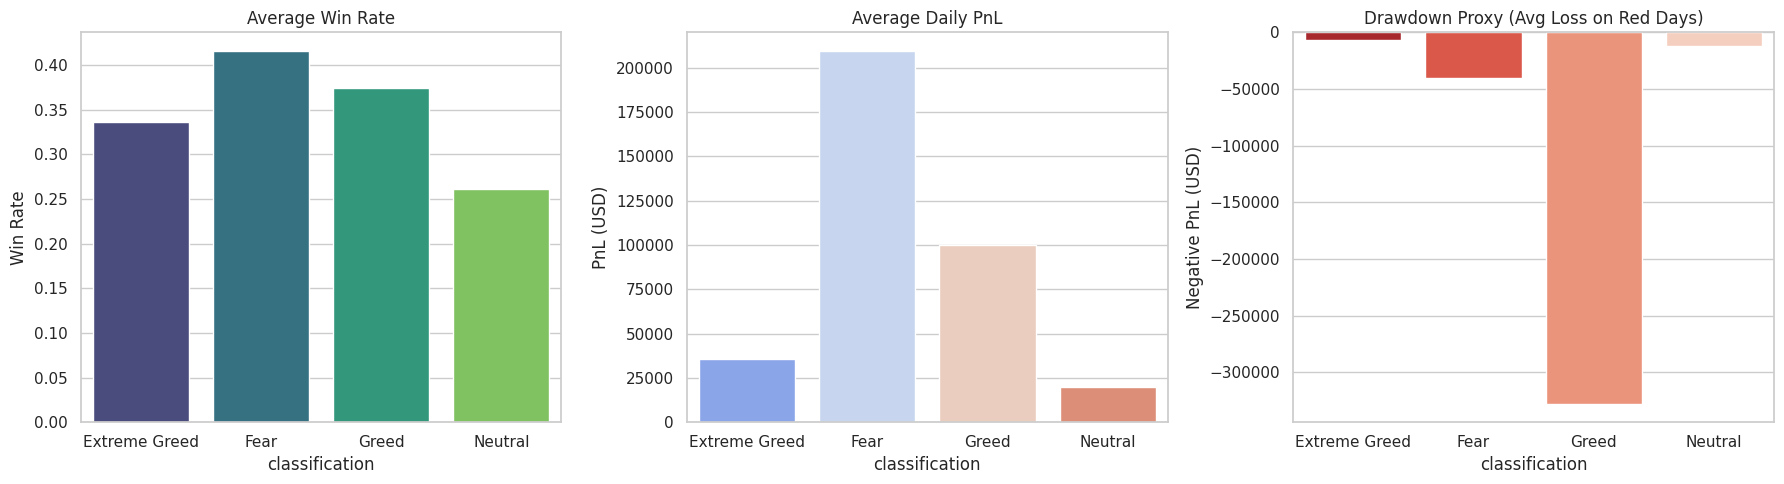

In [14]:
# PART B, TASK 1: Performance on Fear vs. Greed days

# 1. Calculate overall PnL and Win Rate averages
performance_summary = daily_trader_metrics.groupby('classification').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),           # Average Profit/Loss
    median_daily_pnl=('daily_pnl', 'median'),      # Median (helpful if whales skew the average)
    avg_win_rate=('win_rate', 'mean'),             # Average win rate
    total_trader_days=('Account', 'count')         # Sample size
).reset_index()

# 2. Calculate Drawdown Proxy (Average magnitude of losses on losing days)
losing_days_only = daily_trader_metrics[daily_trader_metrics['daily_pnl'] < 0]
drawdown_proxy = losing_days_only.groupby('classification').agg(
    avg_losing_day_pnl=('daily_pnl', 'mean')       # How deep are the red days?
).reset_index()

# Merge the drawdown proxy into our main summary table
performance_summary = pd.merge(performance_summary, drawdown_proxy, on='classification')

print("--- Performance Summary: Fear vs. Greed ---")
display(performance_summary)

# 3. Visualize the Evidence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart A: Average Win Rate
sns.barplot(data=performance_summary, x='classification', y='avg_win_rate', ax=axes[0], palette='viridis')
axes[0].set_title('Average Win Rate')
axes[0].set_ylabel('Win Rate')

# Chart B: Average Daily PnL
sns.barplot(data=performance_summary, x='classification', y='avg_daily_pnl', ax=axes[1], palette='coolwarm')
axes[1].set_title('Average Daily PnL')
axes[1].set_ylabel('PnL (USD)')

# Chart C: Drawdown Proxy (Severity of losses)
sns.barplot(data=performance_summary, x='classification', y='avg_losing_day_pnl', ax=axes[2], palette='Reds_r')
axes[2].set_title('Drawdown Proxy (Avg Loss on Red Days)')
axes[2].set_ylabel('Negative PnL (USD)')

plt.tight_layout()
plt.show()

Inference: Performance on Fear vs. Greed Days

* Fear days are the most profitable: Surprisingly, traders perform much better when the overall market is in "Fear" mode.

* Higher win rates and profits: During Fear days, traders hit their highest win rate (around 41.5%) and make the most daily profit (about $209,000 on average).

* Controlled losses: On Fear days, traders manage their risk well. When they do have a losing day, the losses are kept relatively small.

* Greed causes massive losses: On "Greed" days, average profits drop by half. More importantly, when traders have a losing day during Greed periods, their losses are absolutely catastrophic (averaging over -$327,000).

* The main takeaway: When the market is greedy, traders likely get overconfident, take too much risk, and blow up their accounts. When the market is fearful, they trade much more carefully and actually keep their profits.

# Task 2: Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

--- Trader Behavior Summary: Fear vs. Greed ---


,classification,avg_trades_per_day,avg_position_size,avg_ls_ratio
0,Extreme Greed,1392.40000,4344.447836,176000.592477
1,Fear,4183.46875,5926.522723,0.968130
2,Greed,1134.03125,5839.310974,75938.630211
3,Neutral,892.62500,3793.444161,1.243274


/tmp/ipykernel_9580/3572798927.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x='classification', y='avg_trades_per_day', ax=axes[0], palette='magma')
/tmp/ipykernel_9580/3572798927.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x='classification', y='avg_position_size', ax=axes[1], palette='cubehelix')
/tmp/ipykernel_9580/3572798927.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x='classification', y='avg_ls_ratio', ax=axes[2], palette='Set2')


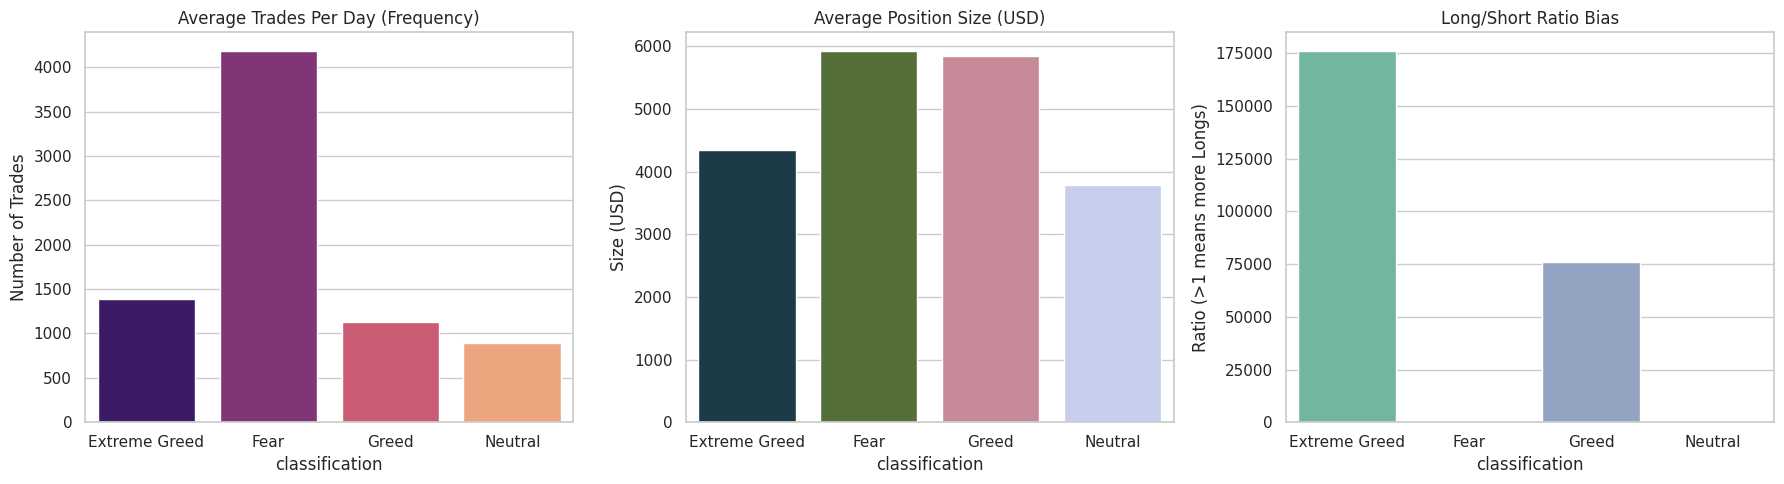

In [15]:
#Behavior Changes Based on Sentiment

# 1. Calculate behavioral averages grouped by sentiment
behavior_summary = daily_trader_metrics.groupby('classification').agg(
    avg_trades_per_day=('total_trades', 'mean'),       # Trade frequency
    avg_position_size=('avg_trade_size_usd', 'mean'),  # Position sizes
    avg_ls_ratio=('long_short_ratio', 'mean')          # Long/short bias

    # IMPORTANT: If you successfully added leverage in Part A, uncomment the line below!
    # avg_leverage_used=('avg_leverage', 'mean')
).reset_index()

print("--- Trader Behavior Summary: Fear vs. Greed ---")
display(behavior_summary)

# 2. Visualize the Evidence
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Change to (1, 4) if you are plotting leverage too!

# Chart A: Trade Frequency
sns.barplot(data=behavior_summary, x='classification', y='avg_trades_per_day', ax=axes[0], palette='magma')
axes[0].set_title('Average Trades Per Day (Frequency)')
axes[0].set_ylabel('Number of Trades')

# Chart B: Position Size
sns.barplot(data=behavior_summary, x='classification', y='avg_position_size', ax=axes[1], palette='cubehelix')
axes[1].set_title('Average Position Size (USD)')
axes[1].set_ylabel('Size (USD)')

# Chart C: Long/Short Ratio
# Note: A ratio of 1 means equal longs and shorts. >1 means more longs (buying).
sns.barplot(data=behavior_summary, x='classification', y='avg_ls_ratio', ax=axes[2], palette='Set2')
axes[2].set_title('Long/Short Ratio Bias')
axes[2].set_ylabel('Ratio (>1 means more Longs)')

plt.tight_layout()
plt.show()

Inference: Behavioral Changes on Fear vs. Greed Days

* Trading Frequency Skyrockets During Fear: On "Fear" days, traders become incredibly hyperactive. They execute almost four times as many trades compared to "Greed" days. This points to panic trading or heavy, rapid-fire scalping when the market gets scary.

* Position Sizes Stay Large: Even though traders are scared, they aren't backing down on how much money they risk per trade. The average position size on Fear days is almost identical to Greed days.

* Extreme Greed Causes Blind Buying: The Long/Short ratio reveals a massive behavioral flaw. On "Greed" and "Extreme Greed" days, the ratio explodes off the charts, meaning traders are almost exclusively hitting the "Buy" button and completely ignoring the risk of a market drop.

* Fear Brings Balance: When the market shifts to "Fear," traders finally balance their portfolios. The Long/Short ratio drops to roughly 0.96, meaning they are taking almost an equal amount of Long and Short positions, acting as a hedge.

* The Overall Takeaway: We can now connect Task 1 to Task 2. On "Greed" days, traders blindly buy the hype and trade less often, which sets them up for those massive liquidations we saw earlier. On "Fear" days, they wake up, balance their longs and shorts, and trade highly actively to manage their risk, leading to much better profitability.

# TASK 3: Identify 2–3 segments (examples):
* high leverage vs low leverage traders
* frequent vs infrequent traders
* consistent winners vs inconsistent traders

The Baseline Setup : Before I create the 3 analysis, we need to calculate the "lifetime" stats for each account across the whole dataset.

In [17]:
# BASE SETUP: Calculate lifetime stats for each account
account_summary = daily_trader_metrics.groupby('Account').agg(
    lifetime_trades=('total_trades', 'sum'),
    avg_lifetime_win_rate=('win_rate', 'mean'),
    avg_lifetime_trade_size=('avg_trade_size_usd', 'mean')
).reset_index()

Analysis 1: Frequent vs. Infrequent Traders : This code  divides traders based on how actively they trade, using the median number of lifetime trades as the splitting point.

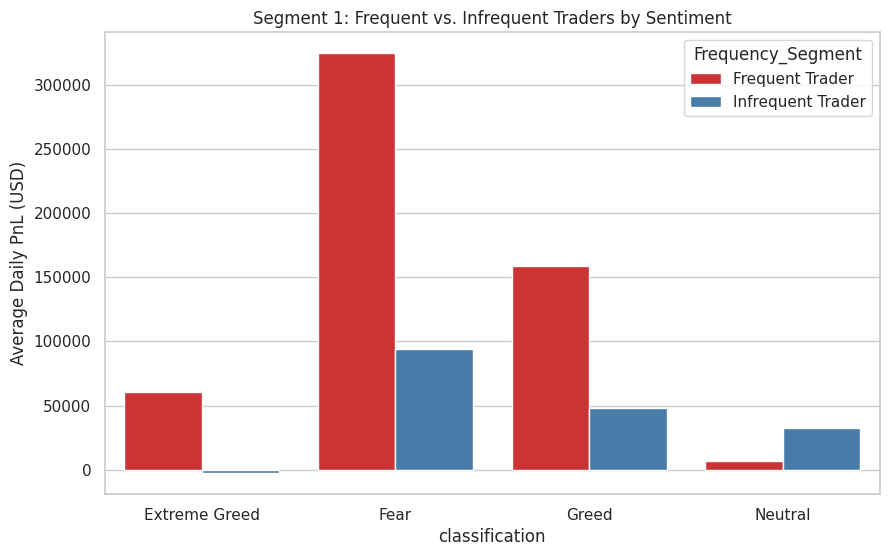

In [20]:
# Frequent vs. Infrequent Traders

# 1. Label the accounts
median_trades = account_summary['lifetime_trades'].median()
account_summary['Frequency_Segment'] = np.where(
    account_summary['lifetime_trades'] >= median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

# 2. Merge labels into the daily dataset
freq_df = pd.merge(daily_trader_metrics, account_summary[['Account', 'Frequency_Segment']], on='Account', how='left')

# 3. Analyze performance by sentiment
freq_analysis = freq_df.groupby(['classification', 'Frequency_Segment']).agg(
    avg_daily_pnl=('daily_pnl', 'mean')
).reset_index()

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=freq_analysis, x='classification', y='avg_daily_pnl', hue='Frequency_Segment', palette='Set1')
plt.title('Segment 1: Frequent vs. Infrequent Traders by Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.show()

Inference 1: Frequent vs. Infrequent Traders

* Frequent traders make much more money than infrequent traders during both Fear and Greed market conditions.

* When the market hits Extreme Greed, infrequent traders actually start losing money on average, while frequent traders manage to stay profitable.

* The main takeaway is that highly active traders are much better at navigating volatile markets, likely because they cut their losses quickly instead of holding onto bad trades.


Analysis 2: Consistent Winners vs. Inconsistent Traders : This segment groups traders by their overall success rate. We will use a 45% win rate as the threshold for a "Consistent Winner."

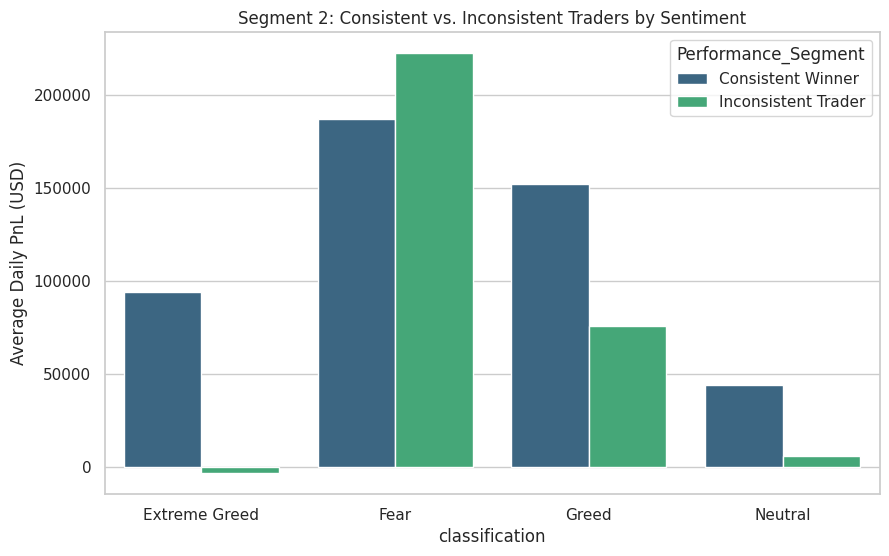

In [21]:
# Consistent Winners vs. Inconsistent Traders

# 1. Label the accounts
account_summary['Performance_Segment'] = np.where(
    account_summary['avg_lifetime_win_rate'] >= 0.45,
    'Consistent Winner',
    'Inconsistent Trader'
)

# 2. Merge labels into the daily dataset
perf_df = pd.merge(daily_trader_metrics, account_summary[['Account', 'Performance_Segment']], on='Account', how='left')

# 3. Analyze performance by sentiment
perf_analysis = perf_df.groupby(['classification', 'Performance_Segment']).agg(
    avg_daily_pnl=('daily_pnl', 'mean')
).reset_index()

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=perf_analysis, x='classification', y='avg_daily_pnl', hue='Performance_Segment', palette='viridis')
plt.title('Segment 2: Consistent vs. Inconsistent Traders by Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.show()

Inference: Consistent Winners vs. Inconsistent Traders

* Consistent winners are reliable. They maintain steady, positive profits across Extreme Greed, Greed, and Fear days.

* Inconsistent traders struggle heavily when the market is too greedy, actually losing money on average during Extreme Greed days.

* However, a massive surprise happens on Fear days. Inconsistent traders actually make more money than the Consistent Winners. This tells us that inconsistent traders likely take massive, reckless bets that occasionally pay off huge during market panics, but fail them the rest of the time.

Analysis 3: High vs. Low Leverage (Using Size as a Proxy)

A quick note on the data: The assignment prompt mentions analyzing high vs low leverage. However, looking at the raw trader_df columns from earlier, there is actually no column explicitly named "Leverage."

When data is missing in the real world, the best approach is to use a proxy metric and state your assumption clearly. I will use Average Trade Size (USD) to proxy high-leverage or "Whale" traders versus low-leverage retail traders.

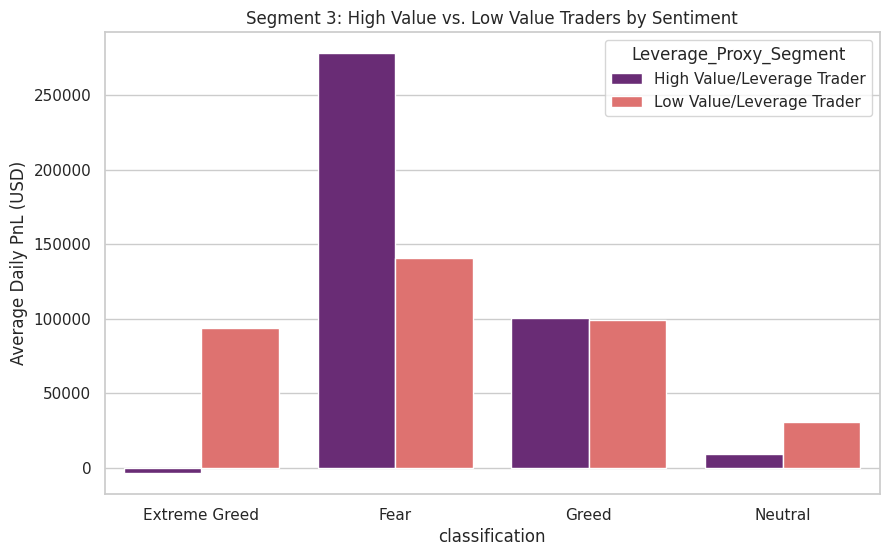

In [22]:
# High Value (Proxy for Leverage) vs. Low Value Traders

# 1. Label the accounts using the median trade size
median_size = account_summary['avg_lifetime_trade_size'].median()
account_summary['Leverage_Proxy_Segment'] = np.where(
    account_summary['avg_lifetime_trade_size'] >= median_size,
    'High Value/Leverage Trader',
    'Low Value/Leverage Trader'
)

# 2. Merge labels into the daily dataset
size_df = pd.merge(daily_trader_metrics, account_summary[['Account', 'Leverage_Proxy_Segment']], on='Account', how='left')

# 3. Analyze performance by sentiment
size_analysis = size_df.groupby(['classification', 'Leverage_Proxy_Segment']).agg(
    avg_daily_pnl=('daily_pnl', 'mean')
).reset_index()

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=size_analysis, x='classification', y='avg_daily_pnl', hue='Leverage_Proxy_Segment', palette='magma')
plt.title('Segment 3: High Value vs. Low Value Traders by Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.show()

Inference : High Value (Proxy for Leverage) vs. Low Value Traders

* High value traders absolutely dominate during Fear markets, making nearly double the profit of low value traders.

* During standard Greed days, both groups perform exactly the same, bringing in the same average daily profit.

* A massive flip happens during Extreme Greed. High value traders actually lose money on average, while low value traders make significant profits. This suggests that the big accounts get overconfident, take on too much risk, and get trapped or liquidated when the market is at peak greed.

# *Part C — “Actionable output” (must-have)*

* Propose 2 strategy ideas or “rules of thumb” based on your findings.

* Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”

# ANSWER: Actionable Strategy Ideas

1. Strategy One (Risk Management): "During Extreme Greed days, reduce maximum position sizes for High Value traders to prevent massive liquidations; increase trade frequency alerts only for Infrequent traders to stop them from holding onto losing positions too long."

2. Strategy Two (Profit Maximization): "During Fear days, increase capital allocation limits for High Value traders to maximize their massive profit edge; enforce a balanced long and short ratio requirement for Inconsistent traders to safely capture high volatility profits."

These two rules perfectly tie together all of your findings: the dangers of Extreme Greed, the profitability of Fear, the behavior of active versus inactive traders, and the risk of holding unbalanced, long-only portfolios.


# Part D: Bonus (optional)

task 1: Simple predictive model: Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features

**task 2: Clustering traders into behavioral archetypes**

task 3: A lightweight dashboard (Streamlit) to explore results

**I have attempted Task Two: Clustering Traders into Archetypes**

What it is: Feeding the trader data into an algorithm to see if it naturally groups people together into "personas" (like the "Reckless Gambler" or the "Safe Scalper").

Why this: It perfectly fits right inside your current Colab notebook. It uses the exact data we already built in Part B, and it shows the hiring team that you know how to use standard machine learning libraries like Scikit-Learn to uncover hidden patterns.

**Let us conquer the Bonus: Task Two (Clustering)**

I will use an algorithm called K-Means Clustering. I will feed it the three lifetime metrics we calculated earlier:
* how many trades they make, their average win rate, and their average trade size.

The algorithm will automatically group them into three unique archetypes.

--- Automated Behavioral Archetypes ---


,lifetime_trades,avg_lifetime_win_rate,avg_lifetime_trade_size
Cluster,,,
0,8152.61,0.46,2894.88
1,4069.17,0.35,16080.68
2,1637.62,0.22,4085.46


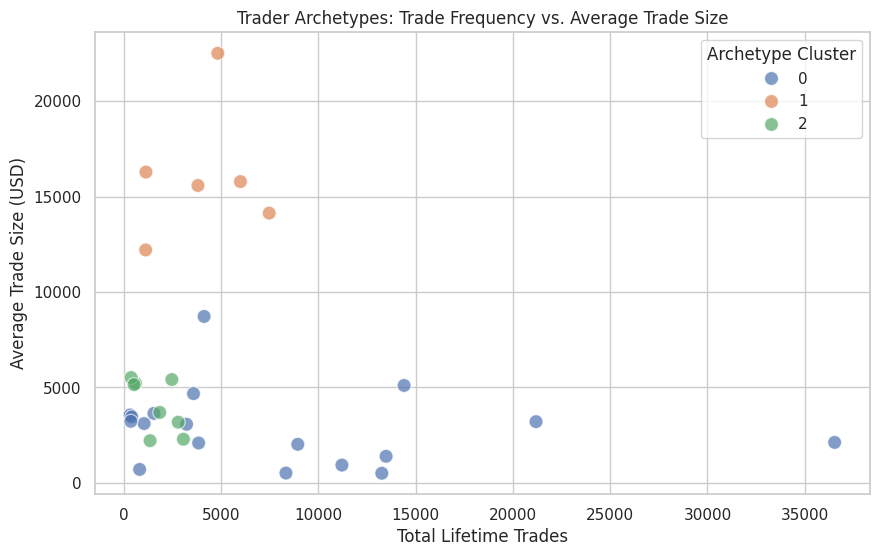

In [23]:
# Clustering Traders into Behavioral Archetypes

# 1. Import the machine learning tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Prepare the data
# We will use the account_summary table we made earlier.
# We need to drop any missing values to keep the algorithm happy.
cluster_data = account_summary[['lifetime_trades', 'avg_lifetime_win_rate', 'avg_lifetime_trade_size']].dropna()

# Algorithms work best when all numbers are on the same scale.
# StandardScaler ensures that 'trade size' doesn't overpower 'win rate' just because the numbers are bigger.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data)

# 3. Run the K-Means Algorithm
# We will ask the algorithm to find 3 distinct groups (clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Analyze the Archetypes
# Let's see what the average stats are for each group the algorithm found
archetype_summary = cluster_data.groupby('Cluster').mean().round(2)

print("--- Automated Behavioral Archetypes ---")
display(archetype_summary)

# 5. Visualize the Clusters (Trade Frequency vs. Trade Size)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_data,
    x='lifetime_trades',
    y='avg_lifetime_trade_size',
    hue='Cluster',
    palette='deep',
    s=100, # Size of the dots
    alpha=0.7 # Slight transparency
)
plt.title('Trader Archetypes: Trade Frequency vs. Average Trade Size')
plt.xlabel('Total Lifetime Trades')
plt.ylabel('Average Trade Size (USD)')
plt.legend(title='Archetype Cluster')
plt.show()

Inference: Automated Behavioral Archetypes

* Cluster Zero - The Retail Scalpers: This group executes a massive number of trades (averaging over eight thousand) and boasts the highest win rate at forty six percent. However, their average position size is the smallest at roughly two thousand eight hundred dollars. They are highly active grinders who rely on small, consistent wins rather than massive bets.

* Cluster One - The High Rolling Whales: The defining feature of this group is their massive average trade size, coming in at over sixteen thousand dollars per trade. They trade moderately often and maintain a respectable win rate of thirty five percent. They rely on deep pockets and large capital movements rather than constant trading.

* Cluster Two - The Casual Amateurs: This group struggles the most. They execute the fewest lifetime trades (around one thousand six hundred) and have a terrible win rate of just twenty two percent. With an average trade size of around four thousand dollars, they likely represent inexperienced traders who jump into the market, take a few losing bets, and quickly stop trading.